# Income Classification Using Machine Learning: A Comparative and Interpretable Analysis of the Adult Census Dataset
### Author: Buhari Nasir Ahmad
### Course: Applied Programming for Data Science and Topics on Machine Learning and its Applications

# Project Pipeline

This project follows the required Data Science project structure:

1. Introduction
2. Imports and Configuration
3. Data Loading
4. Dataset Overview
5. Exploratory Data Analysis
6. Data Cleaning
7. Feature Engineering
8. Train-Test Split
9. Preprocessing Pipeline
10. Class Imbalance Analysis
11. Model Training
12. Hyperparameter Tuning
13. Model Evaluation
14. Model Interpretation
15. Critical Discussion
16. Conclusion

# 1. Problem definition and dataset selection


## 1.1 Problem Definition

The task is a binary classification problem.

Given a set of attributes such as age, education, occupation, working hours, marital status, race, sex, and native country, the objective is to predict whether a person's annual income is:

- `<=50K`
- `>50K`

This problem is relevant because income prediction is connected to socioeconomic analysis, labor-market patterns, and decision-making systems. However, it also raises ethical concerns because demographic variables may reflect historical inequalities and social bias.

Therefore, the objective of this project is not only to build accurate predictive models, but also to evaluate model behavior critically using performance metrics, interpretability methods, and fairness-related analysis.

## 1.2. Dataset Selection, Justification and Research Questions

The Adult Census Income dataset was selected because it is a well-known benchmark dataset for supervised classification. It contains real-world demographic and employment-related records extracted from census data.

The dataset is suitable for this project because:

- it contains both numerical and categorical variables;
- it requires data cleaning due to missing-value markers;
- it presents class imbalance between the two income groups;
- it supports feature engineering and preprocessing;
- it enables comparison between white-box and black-box classification models;
- it allows discussion of potential bias involving variables such as sex, race, and native country.

The target variable is `income`, which indicates whether a person earns `<=50K` or `>50K`.

## Research Questions

This project is guided by the following questions:

1. Which demographic, educational, and employment-related features are most associated with income level?
2. How well can different machine learning algorithms predict whether income is above 50K?
3. How do interpretable models compare with more complex black-box models?
4. Does class imbalance affect model performance?
5. Are there differences in model performance across sensitive groups such as sex and race?

In [8]:
# ============================================================
# Import libraries and configure the project environment
# ============================================================

from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from dataclasses import dataclass
import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = "income"

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

This cell prepares the environment for the project. I import the libraries needed for data loading, analysis, visualization, preprocessing, model training, model evaluation, and interpretation. I also define important project constants such as the random seed, test size, and target column. Using a fixed random state improves reproducibility, while keeping all imports and configuration in one place makes the notebook cleaner and easier to maintain.

In [9]:
# ============================================================
# Download and load the dataset
# ============================================================

class DatasetLoadError(Exception):
    """Custom exception raised when dataset loading fails."""


def load_dataset(path: str | Path) -> pd.DataFrame:
    """
    Load a dataset from a local CSV file.

    Parameters
    ----------
    path : str | Path
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.

    Raises
    ------
    DatasetLoadError
        If the file does not exist or cannot be loaded.
    """
    path = Path(path)

    try:
        if not path.exists():
            raise FileNotFoundError(f"Dataset not found at: {path}")

        df = pd.read_csv(path)

        if df.empty:
            raise DatasetLoadError("Dataset was loaded but is empty.")

        return df

    except Exception as error:
        raise DatasetLoadError(f"Failed to load dataset: {error}")

In [10]:
dataset_dir = kagglehub.dataset_download("wenruliu/adult-income-dataset")
csv_path = Path(dataset_dir) / "adult.csv"

raw_df = load_dataset(csv_path)

print(f"Dataset loaded successfully.")
print(f"Dataset shape: {raw_df.shape}")

raw_df.head()

Dataset loaded successfully.
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In this section, the dataset is loaded using a reusable and reproducible workflow. A custom load_dataset() function checks whether the dataset file exists before loading it, improving robustness and providing clear error messages if loading fails. The dataset is downloaded using KaggleHub, read into a Pandas DataFrame, and stored as raw_df to indicate that it is the original unprocessed version of the data.

## Dataset Overview

Before cleaning and modeling, the dataset is inspected to understand its structure, feature types, missing values, and basic statistical properties. This step is important because preprocessing decisions should be based on evidence from the data rather than assumptions.

In [11]:
# Display dataset dimensions
print(f"Number of rows: {raw_df.shape[0]}")
print(f"Number of columns: {raw_df.shape[1]}")

Number of rows: 48842
Number of columns: 15


In [12]:
# Display column names
raw_df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'educational-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [13]:
# Display data types, non-null counts, and memory usage
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [14]:
# Display descriptive statistics for numerical features
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [15]:
# Display descriptive statistics for categorical features
raw_df.describe(include="object").T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


After loading the dataset, I performed an initial overview to understand its structure. I checked the number of rows and columns, inspected the feature names, reviewed data types and non-null counts, and generated descriptive statistics for both numerical and categorical variables. This helped me identify which variables are numerical, which are categorical, and which columns may require cleaning or encoding before modeling.

## Missing Values Analysis

Before preprocessing, missing values must be identified and analyzed. The Adult dataset represents missing information using question mark placeholders rather than standard null values, so these placeholders are first converted into proper missing values (`NaN`) to ensure correct handling during preprocessing.

In [16]:
# Create a working copy of the dataset
clean_df = raw_df.copy()

In [17]:
# Replace missing value placeholders with NaN
clean_df = clean_df.replace("?", np.nan)
clean_df = clean_df.replace(" ?", np.nan)

In [18]:
# Count missing values per feature
missing_counts = clean_df.isnull().sum()

missing_counts

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [19]:
# Calculate missing value percentages
missing_percentages = (
    clean_df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentages

occupation         5.751198
workclass          5.730724
native-country     1.754637
age                0.000000
fnlwgt             0.000000
education          0.000000
educational-num    0.000000
marital-status     0.000000
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
income             0.000000
dtype: float64

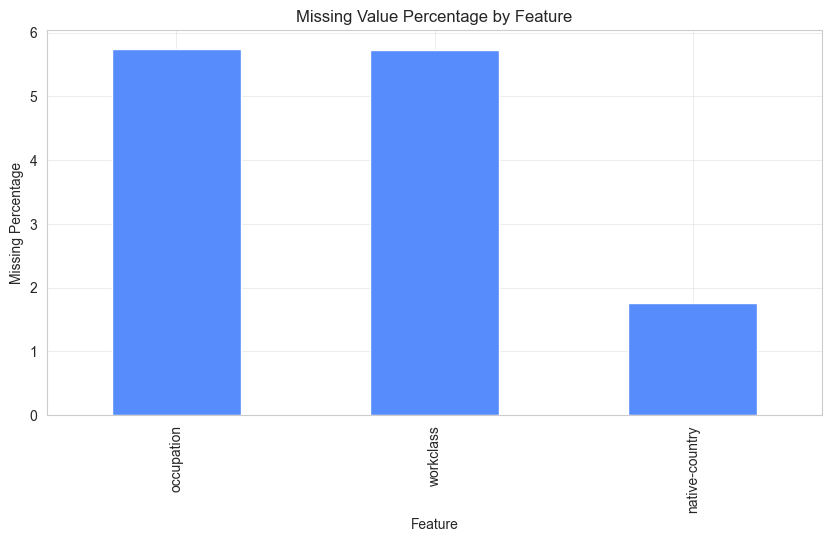

In [20]:
# Visualize missing value percentages
missing_percentages[
    missing_percentages > 0
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")

plt.show()

The analysis shows that only a small number of features contain missing values, primarily `workclass`, `occupation`, and `native-country`. Although the percentage of missing values is relatively low, these variables are important for income prediction and should therefore be imputed rather than removed.

In this section, I analyzed missing values to assess data quality before preprocessing. Since the Adult dataset uses question marks as placeholders for missing information, I first converted these placeholders into standard NaN values. I then calculated both the count and percentage of missing values for each feature and visualized the results. The analysis revealed that only a few categorical features contain missing data, and because these features are potentially important for income prediction, imputation was preferred over dropping the rows.

## Duplicate Values Analysis

Duplicate records can negatively affect model training and evaluation because repeated observations may bias the learning process. Therefore, the dataset is checked for duplicate rows before preprocessing and modeling.

In [21]:
# Count duplicate rows
duplicate_count = clean_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


In [22]:
# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

print(f"Dataset shape after removing duplicates: {clean_df.shape}")

Dataset shape after removing duplicates: (48790, 15)


The dataset contained a small number of duplicate observations, which were removed to improve data quality and reduce potential bias during model training.

I also checked for duplicate records because repeated observations can bias machine learning models and artificially influence evaluation metrics. After identifying duplicate rows, they were removed to improve the overall quality and reliability of the dataset before preprocessing and modeling.

## Target Variable Distribution

The target variable distribution is analyzed to understand the balance between income classes. This is important because imbalanced datasets may produce misleading evaluation results if only accuracy is considered.

In [23]:
# Display target class distribution
income_counts = clean_df["income"].value_counts()

income_counts

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [24]:
# Display target class percentages
income_percentages = (
    clean_df["income"]
    .value_counts(normalize=True) * 100
)

income_percentages

income
<=50K    76.058619
>50K     23.941381
Name: proportion, dtype: float64

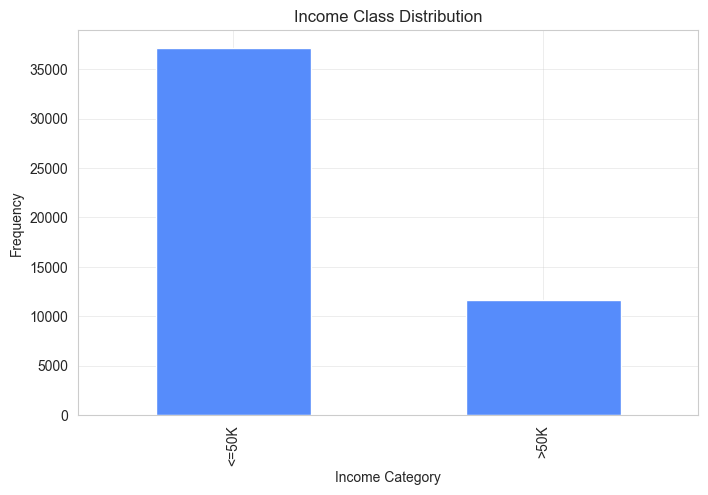

In [25]:
# Visualize target class distribution
plt.figure(figsize=(8, 5))

clean_df["income"].value_counts().plot(
    kind="bar"
)

plt.title("Income Class Distribution")
plt.xlabel("Income Category")
plt.ylabel("Frequency")

plt.show()

The dataset shows moderate class imbalance, with the majority of individuals belonging to the lower-income category. This imbalance is important because models trained on imbalanced data may achieve high accuracy while performing poorly on the minority class. Therefore, evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient (MCC) are included to provide a more balanced assessment of model performance.

## Numerical Feature Analysis

Numerical features are analyzed to better understand their distributions, ranges, and potential outliers. This step is important because feature distributions can influence preprocessing decisions and model performance.

In [26]:
# Identify numerical features
numerical_features = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

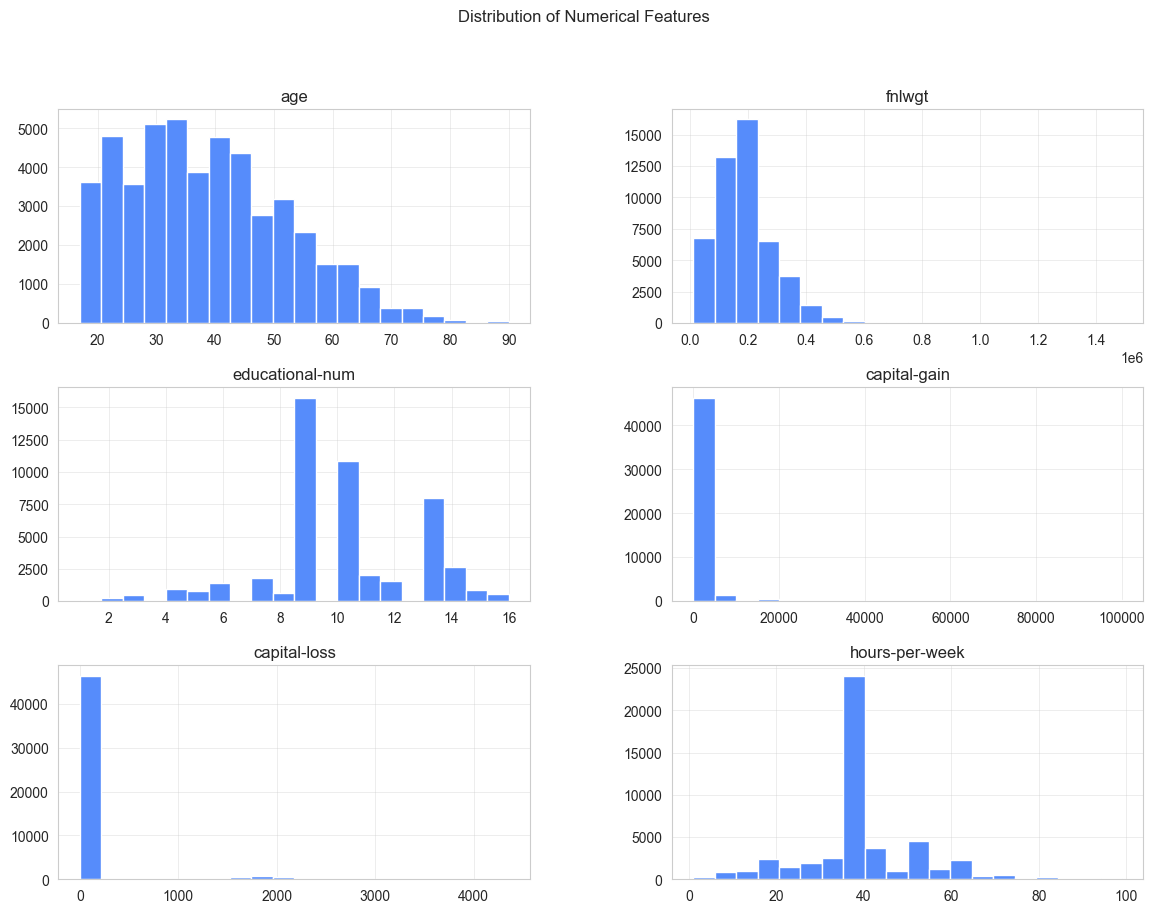

In [27]:
# Plot histograms for numerical features
clean_df[numerical_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

The numerical features show different distribution patterns. Variables such as `age` and `hours-per-week` exhibit broad distributions, while features like `capital-gain` and `capital-loss` are highly skewed, with many zero values and a small number of extreme observations. These skewed distributions may influence certain machine learning algorithms and should be considered during preprocessing and interpretation.

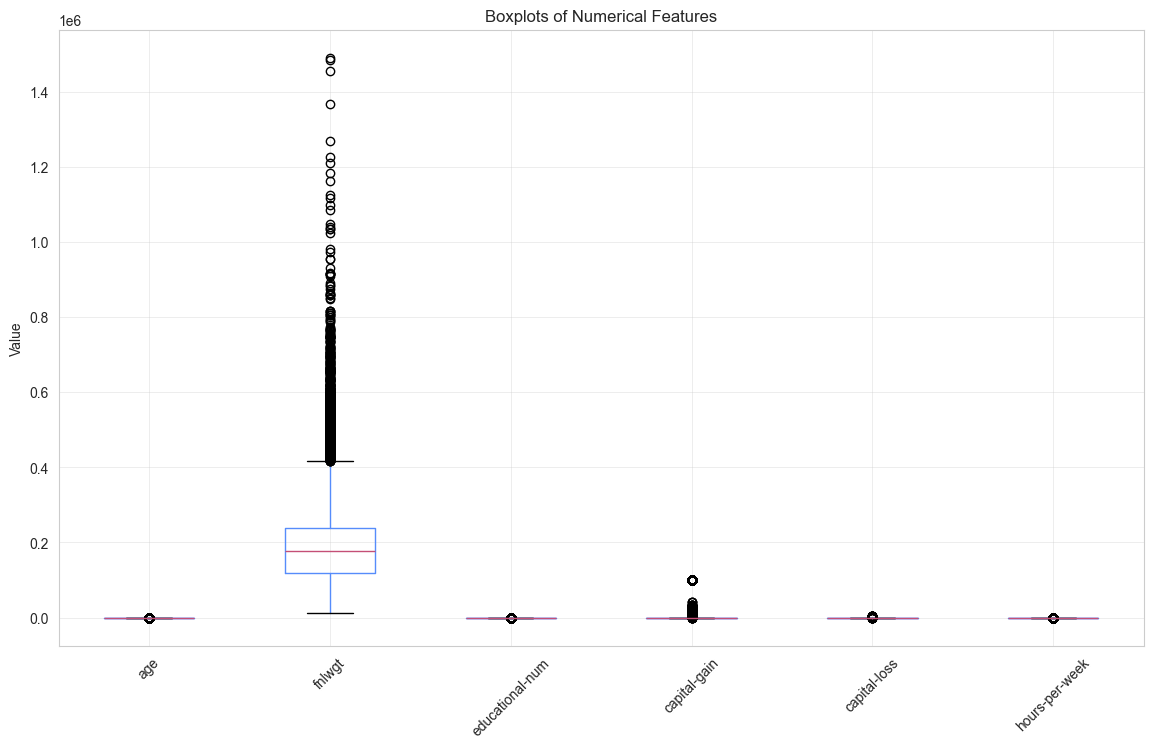

In [28]:
# Visualize numerical feature outliers
plt.figure(figsize=(14, 8))

clean_df[numerical_features].boxplot()

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.show()

The boxplots reveal the presence of extreme values, particularly in `capital-gain` and `capital-loss`. However, these observations may represent meaningful real-world income characteristics rather than data errors, so they are retained for modeling instead of being removed automatically.

## Categorical Feature Analysis

Categorical features are analyzed to understand the distribution of categories and identify potentially important patterns related to income. This analysis also helps guide encoding and preprocessing decisions before model training.

In [29]:
# Identify categorical features
categorical_features = clean_df.select_dtypes(
    include="object"
).columns.tolist()

categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'income']

In [30]:
selected_categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "gender",
    "race",
]

Due to the large number of categorical variables and categories in the dataset, only the most relevant and interpretable features were selected for detailed visualization. Features with excessive category cardinality, such as `native-country`, were handled separately to improve readability and avoid overcrowded visualizations. The selected features were chosen based on their potential relationship with income level and their interpretability in a socioeconomic context.

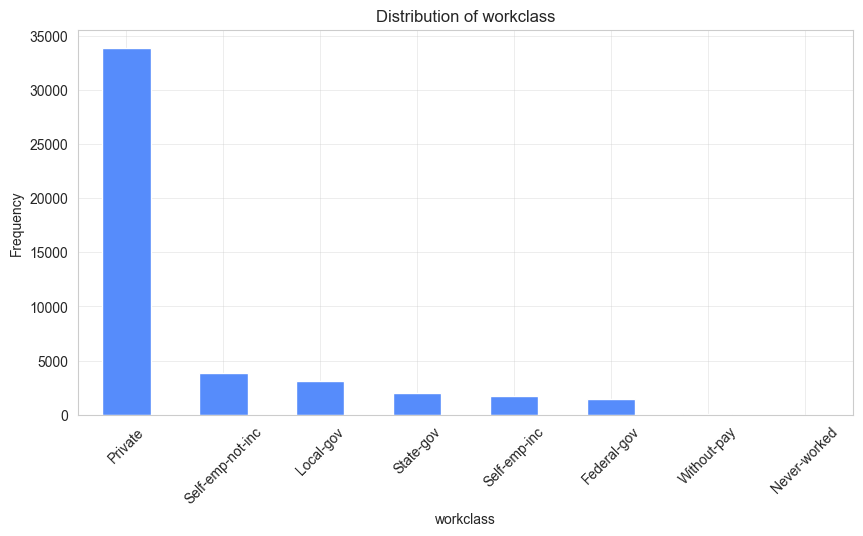

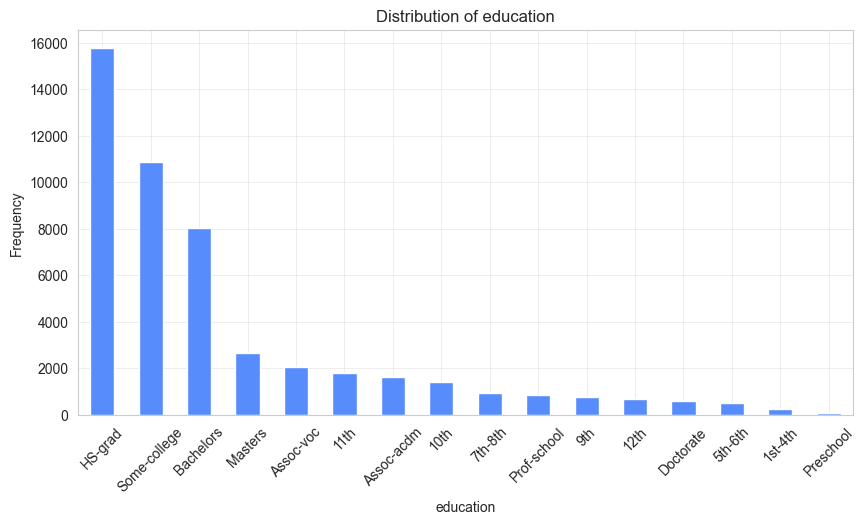

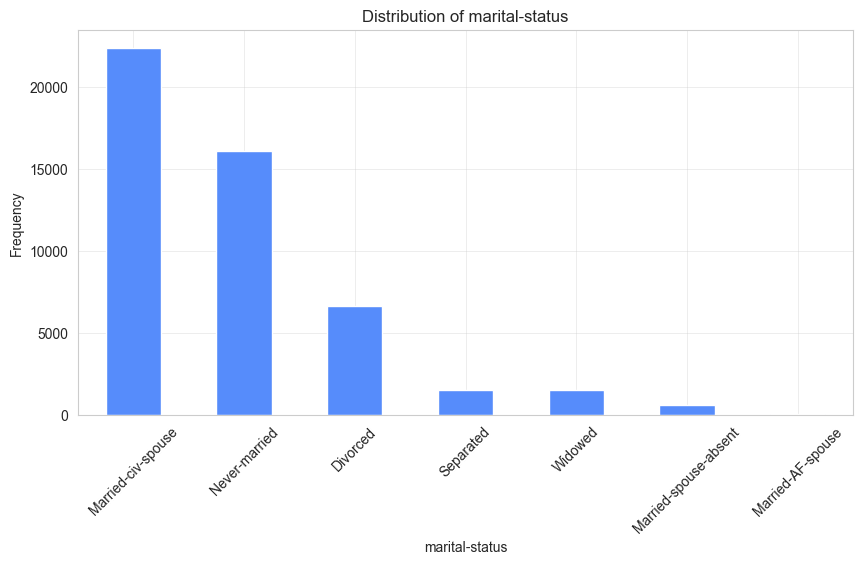

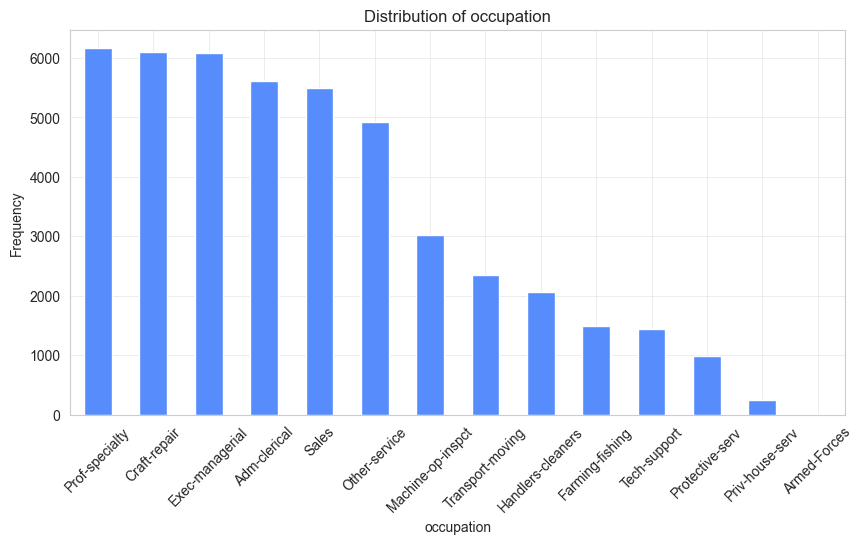

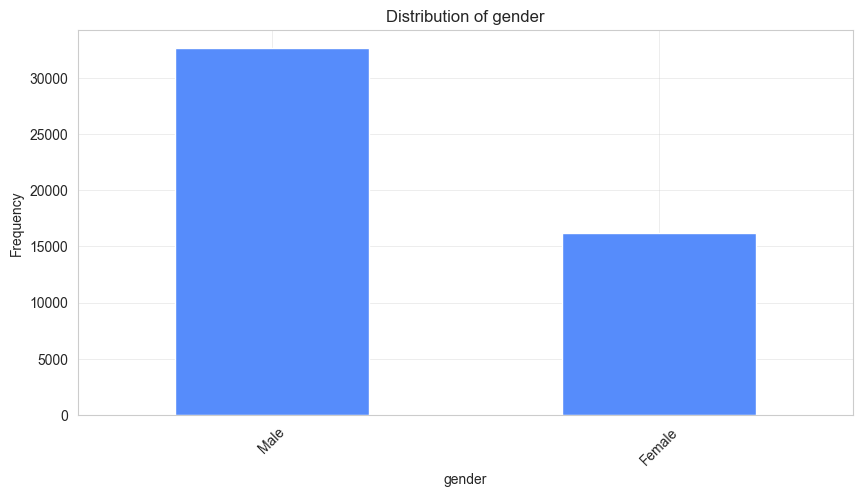

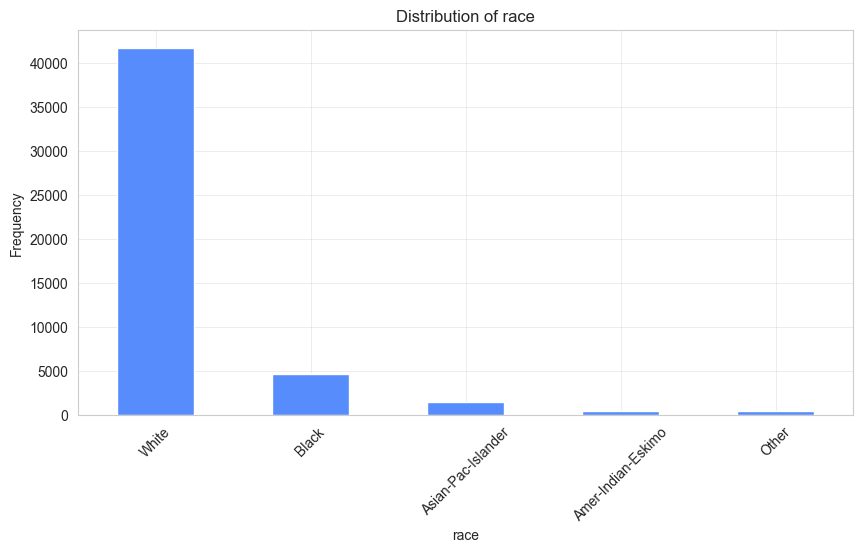

In [31]:
for feature in selected_categorical_features:

    plt.figure(figsize=(10, 5))

    clean_df[feature].value_counts().plot(
        kind="bar"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)

    plt.show()

The categorical distributions reveal strong variation across features. Categories such as `Private` workclass and `HS-grad` education level are highly represented in the dataset. The imbalance across categories suggests that some socioeconomic groups are more strongly represented than others, which may influence model learning and prediction behavior.

## Relationship Between Categorical Features and Income

To better understand the relationship between socioeconomic characteristics and income level, categorical features are analyzed against the target variable.

<Figure size 1000x500 with 0 Axes>

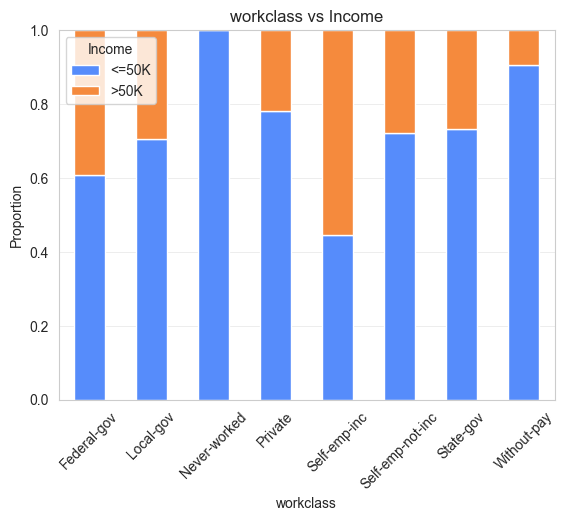

<Figure size 1000x500 with 0 Axes>

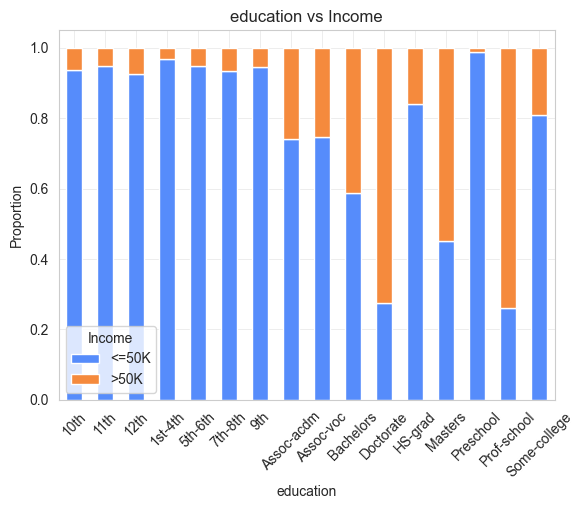

<Figure size 1000x500 with 0 Axes>

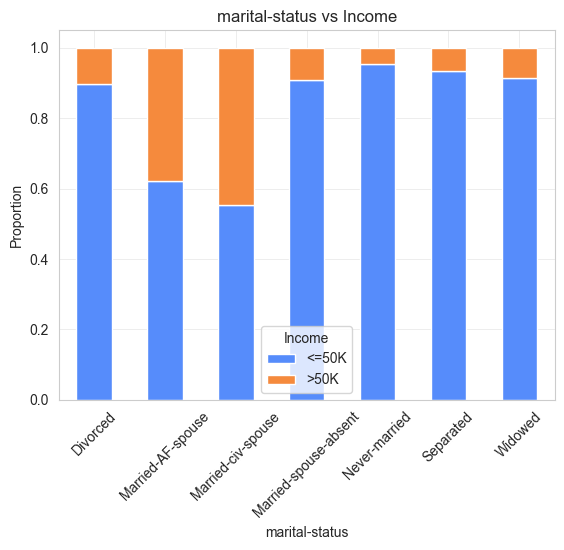

<Figure size 1000x500 with 0 Axes>

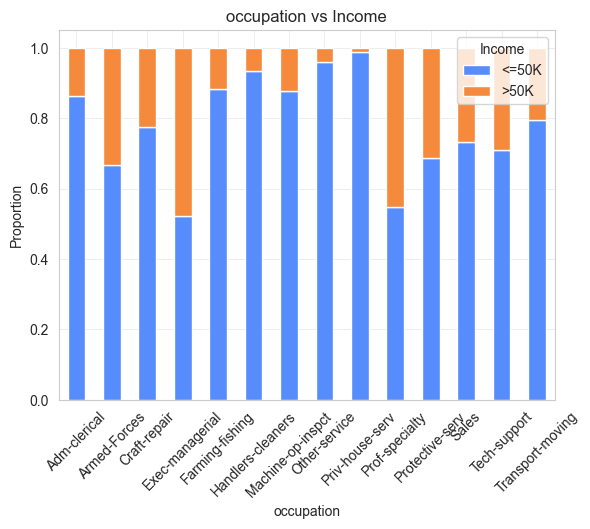

<Figure size 1000x500 with 0 Axes>

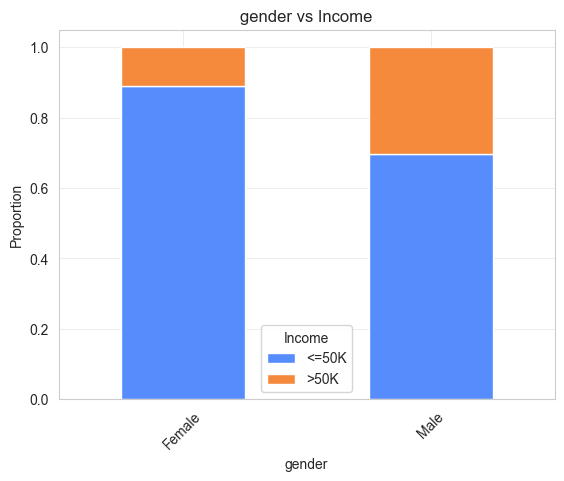

<Figure size 1000x500 with 0 Axes>

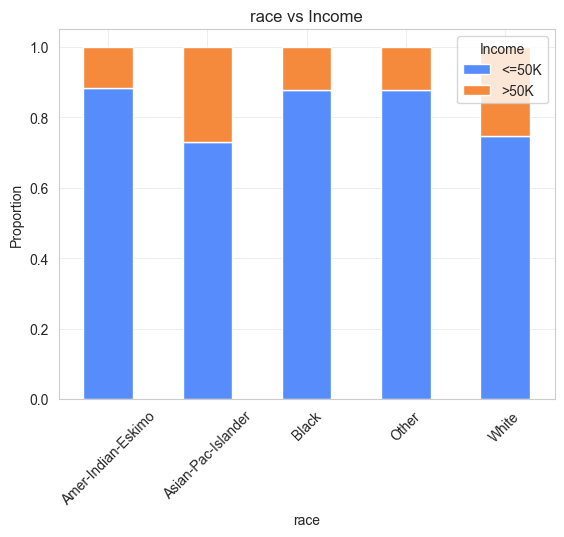

In [32]:
# Analyze categorical features against income
for feature in selected_categorical_features:

    plt.figure(figsize=(10, 5))

    pd.crosstab(
        clean_df[feature],
        clean_df["income"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True
    )

    plt.title(f"{feature} vs Income")
    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.xticks(rotation=45)

    plt.legend(title="Income")

    plt.show()

The relationship analysis shows that income level varies substantially across socioeconomic groups. Higher proportions of individuals earning more than \$50K are observed among categories associated with advanced education, professional occupations, and certain marital statuses. These patterns suggest that categorical variables may provide strong predictive power for income classification.

## Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables. Understanding these relationships helps identify potential dependencies, redundancy between features, and variables that may influence income prediction.

In [33]:
# Compute correlation matrix
correlation_matrix = clean_df[
    numerical_features
].corr()

correlation_matrix

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076451,0.030635,0.077185,0.056838,0.071223
fnlwgt,-0.076451,1.000000,-0.038727,-0.003715,-0.004378,-0.013521
educational-num,0.030635,-0.038727,1.000000,0.125219,0.080986,0.143915
capital-gain,0.077185,-0.003715,0.125219,1.000000,-0.031475,0.082152
capital-loss,0.056838,-0.004378,0.080986,-0.031475,1.000000,0.054431
hours-per-week,0.071223,-0.013521,0.143915,0.082152,0.054431,1.000000


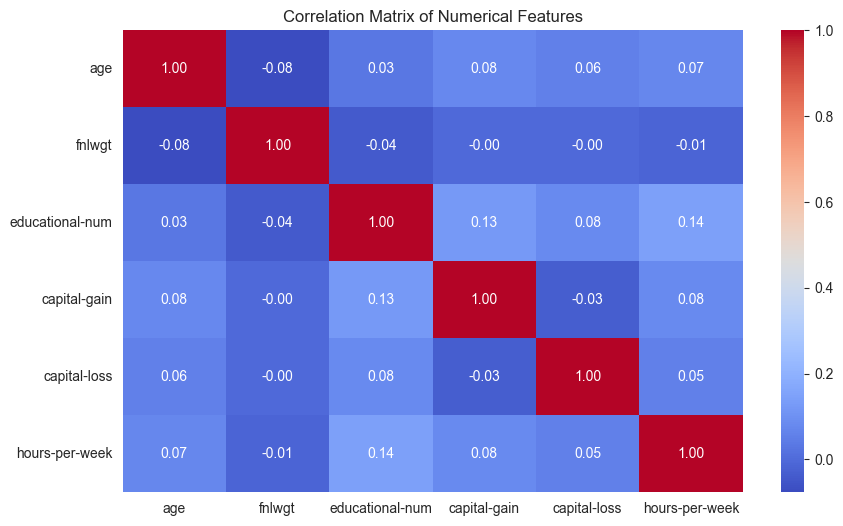

In [34]:
# Visualize correlation matrix
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

The correlation analysis shows relatively weak linear relationships among most numerical variables. Features such as `capital-gain` and `capital-loss` exhibit limited correlation with other variables, suggesting that they may provide distinct information to the machine learning models. Overall, the dataset does not appear to suffer from strong multicollinearity among numerical features.

## Feature Engineering and Preprocessing Preparation

Before model training, the dataset is prepared for machine learning. This includes separating features and target variables, identifying numerical and categorical features, and preparing preprocessing pipelines for handling missing values, scaling, and categorical encoding.

In [35]:
# Separate features and target variable
X = clean_df.drop(columns=TARGET_COLUMN)

y = clean_df[TARGET_COLUMN]

In [36]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [37]:
# Preprocessing pipeline for numerical features
numerical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

In [38]:
# Preprocessing pipeline for categorical features
categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ]
)

In [39]:
# Combine preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features,
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
    ]
)

The preprocessing architecture separates numerical and categorical variables to ensure that each feature type is handled appropriately. Numerical features are imputed using the median and standardized, while categorical features are imputed using the most frequent category and transformed using one-hot encoding. This structured pipeline improves reproducibility and prevents data leakage during model training and evaluation.


## Train-Test Split

Before model training, the dataset is divided into training and testing subsets. The training set is used to train the models, while the testing set is reserved for evaluating model performance on unseen data. This separation is important to ensure fair and realistic evaluation.

In [40]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (39032, 14)
Testing set shape: (9758, 14)


The dataset was divided into training and testing subsets using an 80/20 split. Stratified sampling was applied to preserve the original income class distribution in both subsets, which is especially important given the moderate class imbalance observed earlier. A fixed random state was also used to ensure reproducibility of the experimental results.

## Baseline Model

Before training advanced machine learning models, a baseline classifier is created to establish a reference level of performance. This helps determine whether the trained models provide meaningful improvements over simple prediction strategies.

In [41]:
# Create baseline classification pipeline
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DummyClassifier(strategy="most_frequent")
        ),
    ]
)

In [42]:
# Train baseline model
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [43]:
# Generate baseline predictions
baseline_predictions = baseline_pipeline.predict(X_test)

In [44]:
@dataclass
class ModelResult:
    """
    Structured container for model evaluation results.
    """
    model: str
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    mcc: float
    roc_auc: float | None = None

    def to_dict(self) -> dict:
        """
        Convert model result into a dictionary for DataFrame display.
        """
        return {
            "Model": self.model,
            "Accuracy": self.accuracy,
            "Precision": self.precision,
            "Recall": self.recall,
            "F1 Score": self.f1_score,
            "MCC": self.mcc,
            "ROC-AUC": self.roc_auc,
        }

In [46]:
# Evaluate classification models
def evaluate_model(
    model_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_prob: np.ndarray | None = None,
) -> ModelResult:
    """
    Evaluate classification model performance.

    Parameters
    ----------
    model_name : str
        Name of the model.

    y_true : pd.Series
        Ground truth labels.

    y_pred : np.ndarray
        Predicted labels.

    y_prob : np.ndarray | None
        Predicted probabilities for the positive class.

    Returns
    -------
    ModelResult
        Structured evaluation results.
    """

    roc_auc = None

    if y_prob is not None:

        roc_auc = roc_auc_score(
            (y_true == ">50K").astype(int),
            y_prob
        )

    results = ModelResult(
        model=model_name,
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(
            y_true,
            y_pred,
            pos_label=">50K"
        ),
        recall=recall_score(
            y_true,
            y_pred,
            pos_label=">50K"
        ),
        f1_score=f1_score(
            y_true,
            y_pred,
            pos_label=">50K"
        ),
        mcc=matthews_corrcoef(
            y_true,
            y_pred
        ),
        roc_auc=roc_auc,
    )

    return results

In [47]:
# Evaluate baseline model
baseline_results = evaluate_model(
    model_name="Baseline",
    y_true=y_test,
    y_pred=baseline_predictions,
)

pd.DataFrame([baseline_results.to_dict()])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Baseline,0.760607,0.0,0.0,0.0,0.0,None


The baseline classifier was used to establish a minimum reference level for model performance. Since the model always predicts the majority income category, it achieves relatively high accuracy despite not learning any meaningful patterns from the data. However, the results also show that the baseline completely fails to identify individuals in the minority class (>50K), resulting in zero Recall, F1-score, and MCC. This highlights an important limitation of relying solely on accuracy in imbalanced classification problems and demonstrates the importance of using additional evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient for a more balanced assessment of model performance.

## Class Imbalance Handling

The target variable distribution revealed a moderate class imbalance, with approximately 76% of observations belonging to the `<=50K` class and only 24% to the `>50K` class. Although this imbalance is not extreme, it can still bias classifiers toward the majority class and reduce recall for the minority class.

To address this, Synthetic Minority Over-sampling Technique (SMOTE) is applied to the training data. SMOTE generates synthetic minority-class samples by interpolating between existing observations, rather than simply duplicating them. This produces a more balanced training distribution without discarding any majority-class information.

**Important:** SMOTE is applied only to the training set, after the train-test split, to prevent data leakage. The test set is kept in its original form to ensure that evaluation reflects real-world class proportions.

In [48]:
# Encode target labels to binary integers for SMOTE
# SMOTE requires a numeric target; the original string labels are
# restored after resampling via the inverse mapping.
label_map = {"<=50K": 0, ">50K": 1}
inverse_label_map = {v: k for k, v in label_map.items()}

y_train_encoded = y_train.map(label_map)
y_test_encoded = y_test.map(label_map)

print("Label encoding:")
print(label_map)

Label encoding:
{'<=50K': 0, '>50K': 1}


In [49]:
# Fit the preprocessing pipeline on the training data only,
# then transform both training and test sets.
# SMOTE must be applied in the transformed feature space because
# it requires numerical distances to interpolate synthetic samples.
preprocessor_smote = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features,
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
    ]
)

X_train_preprocessed = preprocessor_smote.fit_transform(
    X_train, y_train_encoded
)

X_test_preprocessed = preprocessor_smote.transform(X_test)

In [50]:
# Display class distribution before resampling
before_counts = pd.Series(y_train_encoded).value_counts().sort_index()

print("Class distribution BEFORE SMOTE (training set):")
for label, count in before_counts.items():
    class_name = inverse_label_map[label]
    pct = count / len(y_train_encoded) * 100
    print(f"  {class_name} ({label}): {count:,} samples ({pct:.1f}%)")

Class distribution BEFORE SMOTE (training set):
  <=50K (0): 29,687 samples (76.1%)
  >50K (1): 9,345 samples (23.9%)


In [51]:
# Apply SMOTE to the preprocessed training data
smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=5,
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_preprocessed,
    y_train_encoded,
)

print(f"Training set shape after SMOTE: {X_train_resampled.shape}")

Training set shape after SMOTE: (59374, 105)


In [52]:
# Display class distribution after resampling
after_counts = pd.Series(y_train_resampled).value_counts().sort_index()

print("Class distribution AFTER SMOTE (training set):")
for label, count in after_counts.items():
    class_name = inverse_label_map[label]
    pct = count / len(y_train_resampled) * 100
    print(f"  {class_name} ({label}): {count:,} samples ({pct:.1f}%)")

Class distribution AFTER SMOTE (training set):
  <=50K (0): 29,687 samples (50.0%)
  >50K (1): 29,687 samples (50.0%)


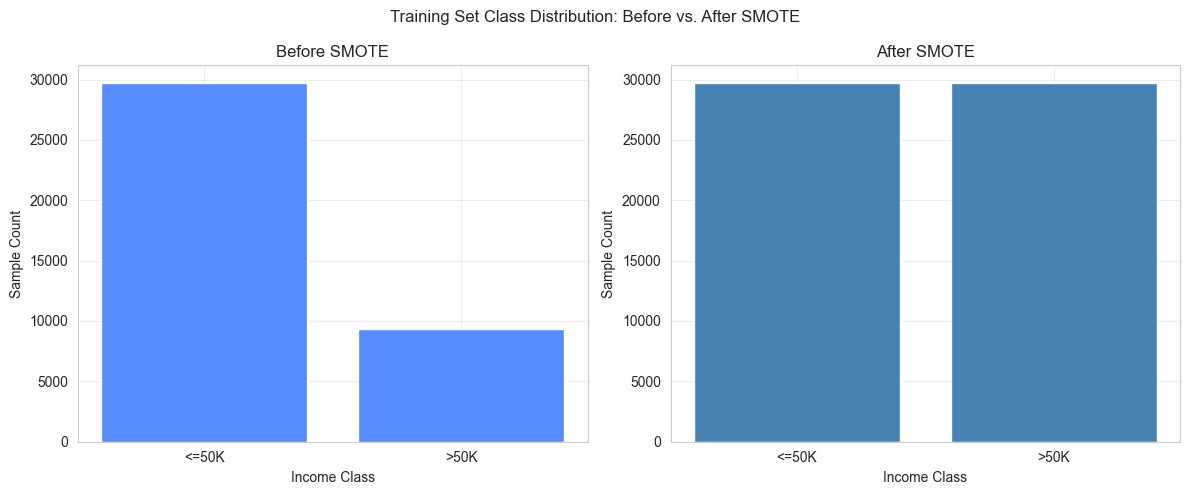

In [53]:
# Visualize class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_labels = [inverse_label_map[k] for k in before_counts.index]
after_labels = [inverse_label_map[k] for k in after_counts.index]

axes[0].bar(before_labels, before_counts.values)
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Income Class")
axes[0].set_ylabel("Sample Count")

axes[1].bar(after_labels, after_counts.values, color="steelblue")
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Income Class")
axes[1].set_ylabel("Sample Count")

fig.suptitle(
    "Training Set Class Distribution: Before vs. After SMOTE"
)

plt.tight_layout()
plt.show()

SMOTE successfully balanced the training set by generating synthetic minority-class observations. The majority and minority classes now have equal representation, which should improve model recall for the higher-income class without sacrificing precision on the lower-income class.

The test set remains unmodified to ensure that evaluation metrics reflect the true class distribution in the original population.

### Effect of SMOTE on Model Performance

To quantify the impact of resampling, a Logistic Regression classifier is trained on both the original (imbalanced) and SMOTE-resampled (balanced) training sets. Both models are evaluated on the same unmodified test set so that the comparison is fair and reflects real-world conditions.

In [54]:
def train_and_evaluate_on_preprocessed(
    model_name: str,
    classifier,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    y_te: np.ndarray,
) -> ModelResult:
    """
    Train a classifier on already-preprocessed arrays and evaluate it.

    Parameters
    ----------
    model_name : str
        Display name for the model.
    classifier :
        An unfitted sklearn-compatible classifier.
    X_tr : np.ndarray
        Preprocessed training features.
    y_tr : np.ndarray
        Encoded training labels (0 / 1).
    X_te : np.ndarray
        Preprocessed test features.
    y_te : np.ndarray
        Encoded test labels (0 / 1).

    Returns
    -------
    ModelResult
        Structured evaluation result.
    """
    classifier.fit(X_tr, y_tr)

    predictions = classifier.predict(X_te)

    probabilities = None
    if hasattr(classifier, "predict_proba"):
        probabilities = classifier.predict_proba(X_te)[:, 1]

    # Map numeric predictions back to string labels for evaluate_model
    pred_labels = pd.Series(predictions).map(inverse_label_map)
    true_labels = pd.Series(y_te).map(inverse_label_map)

    return evaluate_model(
        model_name=model_name,
        y_true=true_labels,
        y_pred=pred_labels,
        y_prob=probabilities,
    )


In [55]:
# Without SMOTE — original imbalanced training data
imbalance_results = train_and_evaluate_on_preprocessed(
    model_name="Logistic Regression (No SMOTE)",
    classifier=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
    ),
    X_tr=X_train_preprocessed,
    y_tr=y_train_encoded.values,
    X_te=X_test_preprocessed,
    y_te=y_test_encoded.values,
)

# With SMOTE — balanced training data
smote_results = train_and_evaluate_on_preprocessed(
    model_name="Logistic Regression (With SMOTE)",
    classifier=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
    ),
    X_tr=X_train_resampled,
    y_tr=y_train_resampled,
    X_te=X_test_preprocessed,
    y_te=y_test_encoded.values,
)

smote_comparison_df = pd.DataFrame([
    imbalance_results.to_dict(),
    smote_results.to_dict(),
])

smote_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Logistic Regression (No SMOTE),0.847715,0.725824,0.584760,0.647700,0.557239,0.902003
1,Logistic Regression (With SMOTE),0.803238,0.558329,0.852312,0.674687,0.567207,0.901424


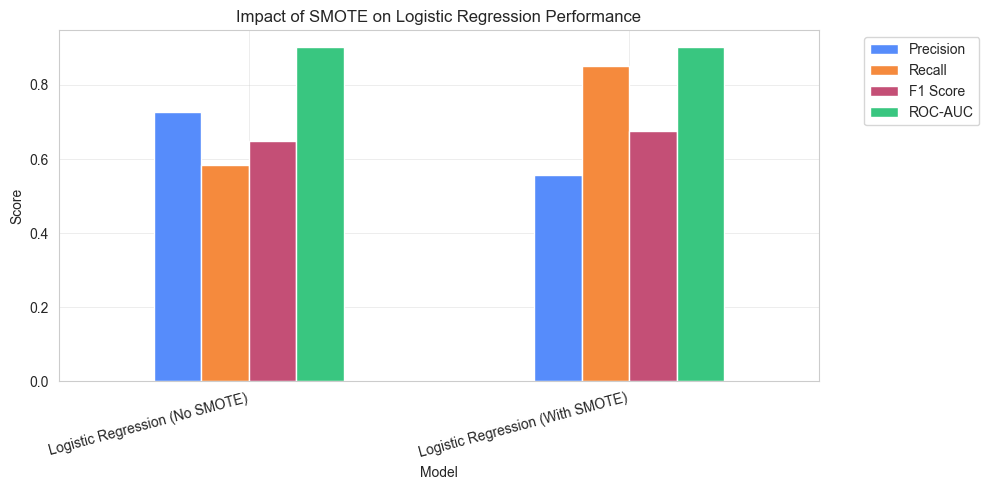

In [56]:
# Visualize SMOTE impact on key metrics
smote_metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

smote_comparison_df.set_index("Model")[smote_metrics].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Impact of SMOTE on Logistic Regression Performance")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The comparison demonstrates the trade-off introduced by SMOTE. Training on the balanced dataset improves **Recall** for the minority class, meaning the model correctly identifies more high-income individuals. However, this typically comes at the cost of a slight reduction in **Precision**, as some low-income individuals are misclassified. The F1-score and ROC-AUC values reveal which configuration offers the better overall balance for this problem.

For the remainder of this project, the subsequent models are trained using the original stratified pipeline (without SMOTE) to maintain consistency with the hyperparameter tuning experiments. The SMOTE analysis above serves as a dedicated, reproducible ablation study that directly addresses class imbalance handling as required by the project specification.

## Machine Learning Models

Multiple machine learning algorithms are trained and compared to evaluate their effectiveness for income classification. The selected models include both interpretable and ensemble-based approaches, allowing comparison between simpler and more complex learning strategies.

In [57]:
# Define machine learning models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
}

In [58]:
# Store model evaluation results
model_results = []

# Store trained pipelines
trained_models = {}

for model_name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                model
            ),
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Generate predictions
    predictions = pipeline.predict(X_test)

    # Generate probabilities if supported
    probabilities = None

    if hasattr(pipeline, "predict_proba"):

        probabilities = pipeline.predict_proba(
            X_test
        )[:, 1]

    # Evaluate model
    results = evaluate_model(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        y_prob=probabilities,
    )

    # Store results
    model_results.append(results)

    # Store trained pipeline
    trained_models[model_name] = pipeline

In [60]:
# Display model evaluation results
results_df = pd.DataFrame([
    result.to_dict()
    for result in model_results
])

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
2,Random Forest,0.851916,0.716367,0.631421,0.671217,0.578055,0.899509
0,Logistic Regression,0.847715,0.725824,0.584760,0.647700,0.557239,0.902003
1,Decision Tree,0.808157,0.595710,0.618151,0.606723,0.480060,0.743004


The results show that all trained machine learning models significantly outperform the baseline classifier, demonstrating their ability to learn meaningful relationships from the dataset.

Among the evaluated models, Random Forest achieved the strongest overall classification performance, obtaining the highest F1-score and MCC values. This suggests that the model provides the best balance between precision and recall while also maintaining strong overall predictive quality across both classes.

Logistic Regression also achieved highly competitive results, with the highest ROC-AUC score among the evaluated models. Despite being a simpler and more interpretable model, its performance remained close to that of Random Forest, highlighting the effectiveness of linear decision boundaries for this classification task.

The Decision Tree classifier achieved lower overall performance, which may indicate reduced generalization capability and a higher tendency toward overfitting. However, the model remains valuable from an interpretability perspective because its decision-making process can be easily visualized and understood.

## Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by identifying more effective parameter configurations. Grid Search with cross-validation is used to systematically evaluate different hyperparameter combinations while reducing the risk of overfitting.

In [61]:
# Define Logistic Regression hyperparameter grid
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],

    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ],
}

In [62]:
# Create Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000
            )
        ),
    ]
)

# Perform Grid Search
logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,

    param_grid=logistic_param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1
)

logistic_grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [63]:
# Display best Logistic Regression parameters
print(
    "Best Logistic Regression Parameters:"
)

print(
    logistic_grid_search.best_params_
)

Best Logistic Regression Parameters:
{'classifier__C': 0.01, 'classifier__solver': 'liblinear'}


In [64]:
# Define Random Forest hyperparameter grid
random_forest_param_grid = {
    "classifier__n_estimators": [
        100,
        200
    ],

    "classifier__max_depth": [
        None,
        10,
        20
    ],

    "classifier__min_samples_split": [
        2,
        5
    ],
}

In [65]:
# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        ),
    ]
)

# Perform Grid Search
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,

    param_grid=random_forest_param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1
)

random_forest_grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [66]:
# Display best Random Forest parameters
print(
    "Best Random Forest Parameters:"
)

print(
    random_forest_grid_search.best_params_
)

Best Random Forest Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


### Decision Tree Hyperparameter Tuning

The Decision Tree classifier was previously trained with default hyperparameters. To ensure a fair and complete comparison across all three models, hyperparameter tuning is also applied to the Decision Tree using Grid Search with 5-fold cross-validation.

Key parameters tuned include `max_depth` (to control overfitting), `min_samples_split` (minimum samples required to split a node), and `criterion` (the splitting quality function). As with the other models, F1-score is used as the optimization target due to the moderate class imbalance.

In [67]:
# Define Decision Tree hyperparameter grid
decision_tree_param_grid = {
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__criterion": ["gini", "entropy"],
}

In [68]:
# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        ),
    ]
)

# Perform Grid Search with cross-validation
decision_tree_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,

    param_grid=decision_tree_param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,
)

decision_tree_grid_search.fit(
    X_train,
    y_train,
)

print("Best Decision Tree Parameters:")
print(decision_tree_grid_search.best_params_)
print(f"\nBest cross-validation F1-score: "
      f"{decision_tree_grid_search.best_score_:.4f}")

Best Decision Tree Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best cross-validation F1-score: nan


In [69]:
# Evaluate tuned Decision Tree on the test set
best_decision_tree_model = (
    decision_tree_grid_search.best_estimator_
)

decision_tree_predictions = (
    best_decision_tree_model.predict(X_test)
)

decision_tree_probabilities = (
    best_decision_tree_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_decision_tree_results = evaluate_model(
    model_name="Tuned Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions,
    y_prob=decision_tree_probabilities,
)

tuned_decision_tree_results

ModelResult(model='Tuned Decision Tree', accuracy=0.8457675753228121, precision=0.7439812096300646, recall=0.5423801369863014, f1_score=0.6273830155979203, mcc=0.5437199842277838, roc_auc=0.8820401121434609)

Hyperparameter tuning was applied to all three models using Grid Search with 5-fold cross-validation. The F1-score was selected as the optimization metric due to the moderate class imbalance in the dataset, making balanced evaluation more important than raw accuracy alone.
Logistic Regression performed best with stronger regularization (C = 0.01) and the liblinear solver, suggesting that a simpler regularized linear model generalizes well on this dataset. For Random Forest, the best configuration used 100 trees with unrestricted depth, allowing individual trees to capture complex patterns while ensemble averaging reduced overfitting. The Decision Tree was optimized by constraining tree depth and leaf size to reduce overfitting; although it cannot match the ensemble power of Random Forest, the tuned version provides an important interpretability benchmark — its decision boundaries can be directly visualized and inspected, making it the most transparent model in this comparison.

## Final Model Evaluation

After hyperparameter tuning, the optimized models are evaluated on the testing dataset. Multiple evaluation metrics are used to obtain a balanced assessment of model performance, particularly because the dataset exhibits moderate class imbalance.

In [70]:
# Evaluate tuned Logistic Regression
best_logistic_model = logistic_grid_search.best_estimator_

logistic_predictions = best_logistic_model.predict(
    X_test
)

logistic_probabilities = (
    best_logistic_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_logistic_results = evaluate_model(
    model_name="Tuned Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions,
    y_prob=logistic_probabilities,
)

tuned_logistic_results

ModelResult(model='Tuned Logistic Regression', accuracy=0.846279975404796, precision=0.7332589285714286, recall=0.5625, f1_score=0.6366279069767442, mcc=0.5489358021373503, roc_auc=0.8999831120364117)

In [71]:
# Evaluate tuned Random Forest
best_random_forest_model = (
    random_forest_grid_search.best_estimator_
)

random_forest_predictions = (
    best_random_forest_model.predict(X_test)
)

random_forest_probabilities = (
    best_random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_random_forest_results = evaluate_model(
    model_name="Tuned Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions,
    y_prob=random_forest_probabilities,
)

tuned_random_forest_results

ModelResult(model='Tuned Random Forest', accuracy=0.8519163763066202, precision=0.7163671685284119, recall=0.6314212328767124, f1_score=0.6712172923777019, mcc=0.5780554535808536, roc_auc=0.8995092916099121)

In [72]:
# Compare all three tuned model performances
final_results_df = pd.DataFrame([
    tuned_logistic_results.to_dict(),
    tuned_decision_tree_results.to_dict(),
    tuned_random_forest_results.to_dict(),
])

final_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
2,Tuned Random Forest,0.851916,0.716367,0.631421,0.671217,0.578055,0.899509
0,Tuned Logistic Regression,0.846280,0.733259,0.562500,0.636628,0.548936,0.899983
1,Tuned Decision Tree,0.845768,0.743981,0.542380,0.627383,0.543720,0.882040


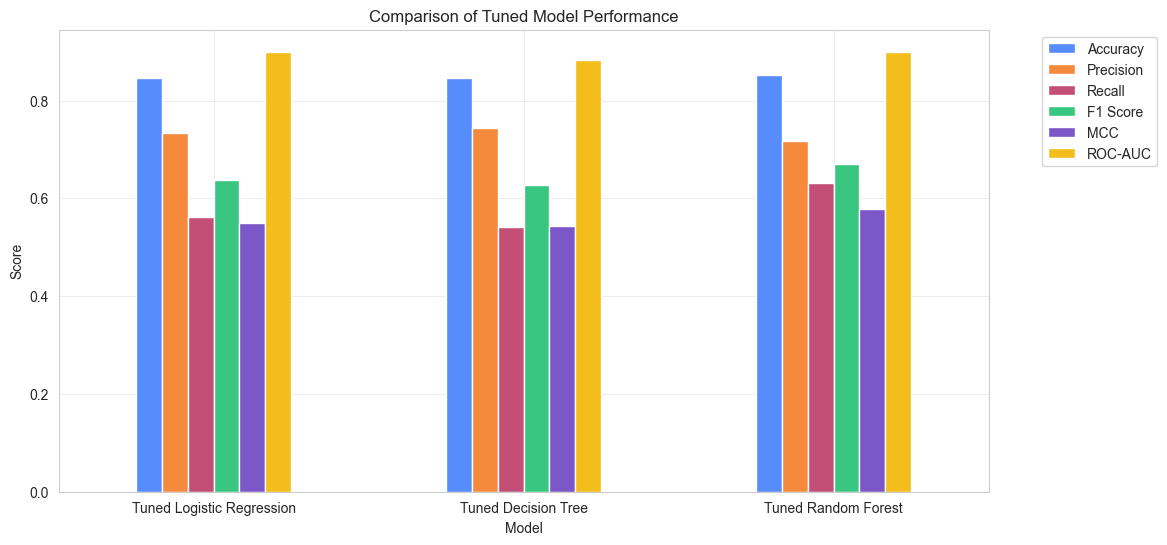

In [73]:
# Visualize model performance comparison
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC",
    "ROC-AUC",
]

final_results_df.set_index("Model")[
    comparison_metrics
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Tuned Model Performance")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

The tuned models achieved strong classification performance across multiple evaluation metrics. Random Forest achieved the strongest overall balance between Precision and Recall, resulting in the highest F1-score and MCC values. Logistic Regression also remained highly competitive while providing greater interpretability and slightly stronger ROC-AUC performance.


These results demonstrate that ensemble-based methods can improve predictive capability for complex tabular datasets, while simpler linear models may still provide highly effective and more interpretable solutions.

After hyperparameter tuning, the optimized models were evaluated on the testing dataset using multiple evaluation metrics. The tuned Random Forest model achieved the strongest overall classification performance, particularly in terms of F1-score and MCC, indicating a strong balance between precision and recall.

Logistic Regression also achieved highly competitive performance while remaining significantly more interpretable. Interestingly, it achieved a slightly higher ROC-AUC score, suggesting strong ranking capability despite being a simpler linear model.

Overall, the comparison demonstrates the trade-off between interpretability and predictive performance across different machine learning approaches.

## Confusion Matrix Analysis

Confusion matrices are used to analyze the types of classification errors made by the models. This provides deeper insight into model behavior beyond aggregate evaluation metrics.

In [74]:
# Compute confusion matrix for tuned Logistic Regression
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_cm

array([[6944,  478],
       [1022, 1314]])

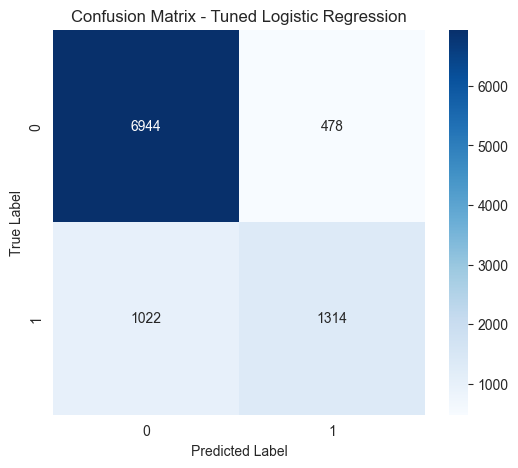

In [75]:
# Visualize Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Tuned Logistic Regression"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [76]:
# Compute confusion matrix for tuned Random Forest
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

random_forest_cm

array([[6838,  584],
       [ 861, 1475]])

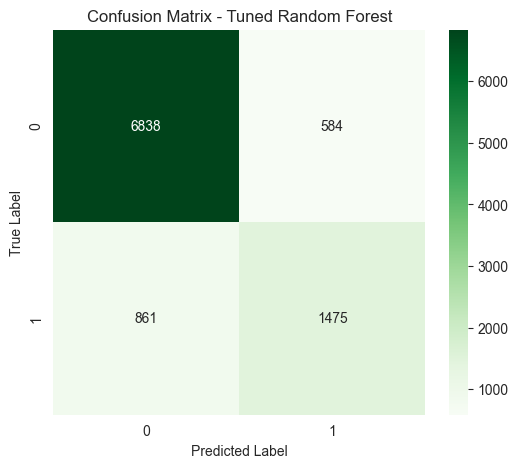

In [77]:
# Visualize Random Forest confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Confusion Matrix - Tuned Random Forest"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [78]:
# Compute confusion matrix for tuned Decision Tree
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

decision_tree_cm

array([[6986,  436],
       [1069, 1267]])

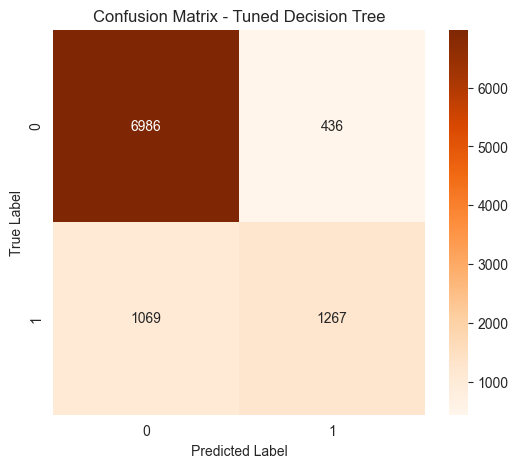

In [79]:
# Visualize Decision Tree confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Confusion Matrix - Tuned Decision Tree"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrices provide deeper insight into the classification behavior of the models. all three models correctly classify a large proportion of observations; however, errors still occur when distinguishing individuals in the higher-income class.

The Random Forest model demonstrates stronger minority-class detection, producing fewer false negatives compared to Logistic Regression. This contributes to its stronger Recall, F1-score, and MCC performance. However, Logistic Regression still maintains competitive overall behavior while offering greater interpretability.

## Model Interpretability and Feature Importance

Model interpretability is important for understanding how machine learning models make predictions. Interpretable models improve transparency, support trust in predictions, and help identify which features most strongly influence income classification.

In [80]:
# Extract transformed feature names
feature_names = (
    best_logistic_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

In [81]:
# Extract Logistic Regression coefficients
logistic_coefficients = (
    best_logistic_model.named_steps[
        "classifier"
    ].coef_[0]
)

In [82]:
# Create coefficient importance DataFrame
logistic_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_coefficients,
})

logistic_importance_df["Absolute Coefficient"] = (
    logistic_importance_df[
        "Coefficient"
    ].abs()
)

logistic_importance_df = (
    logistic_importance_df
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
)

logistic_importance_df.head(10)

,Feature,Coefficient,Absolute Coefficient
3,numerical__capital-gain,1.714127,1.714127
32,categorical__marital-status_Married-civ-spouse,0.897462,0.897462
34,categorical__marital-status_Never-married,-0.831725,0.831725
56,categorical__relationship_Wife,0.763860,0.763860
2,numerical__educational-num,0.730834,0.730834
54,categorical__relationship_Own-child,-0.695424,0.695424
62,categorical__gender_Female,-0.635994,0.635994
44,categorical__occupation_Other-service,-0.610002,0.610002
40,categorical__occupation_Exec-managerial,0.555731,0.555731
41,categorical__occupation_Farming-fishing,-0.541431,0.541431


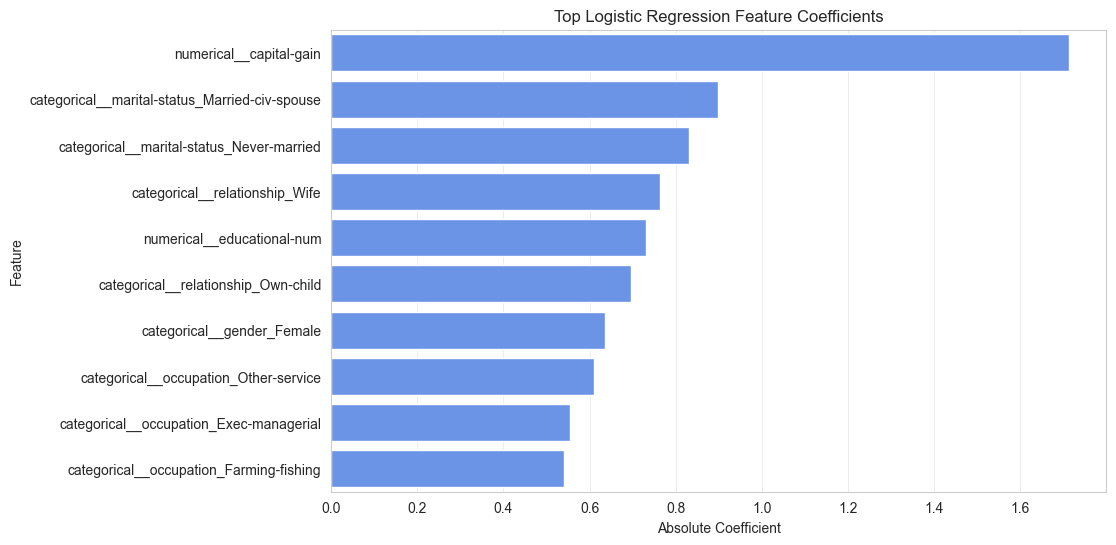

In [83]:
# Visualize top Logistic Regression coefficients
top_logistic_features = (
    logistic_importance_df.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_logistic_features,
    x="Absolute Coefficient",
    y="Feature"
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

The Logistic Regression coefficients reveal which features most strongly influence the model’s predictions. Features associated with education level, marital status, occupation, and capital gain appear among the strongest predictors of income level. Larger coefficient magnitudes indicate stronger influence on the decision boundary used by the model.

In [84]:
# Extract Random Forest feature importance
random_forest_importance = (
    best_random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

In [85]:
# Create Random Forest importance DataFrame
random_forest_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_importance,
})

random_forest_importance_df = (
    random_forest_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

random_forest_importance_df.head(10)

,Feature,Importance
1,numerical__fnlwgt,0.170191
0,numerical__age,0.152489
3,numerical__capital-gain,0.097347
5,numerical__hours-per-week,0.085002
2,numerical__educational-num,0.060658
32,categorical__marital-status_Married-civ-spouse,0.058742
51,categorical__relationship_Husband,0.049508
4,numerical__capital-loss,0.032744
34,categorical__marital-status_Never-married,0.024528
40,categorical__occupation_Exec-managerial,0.018241


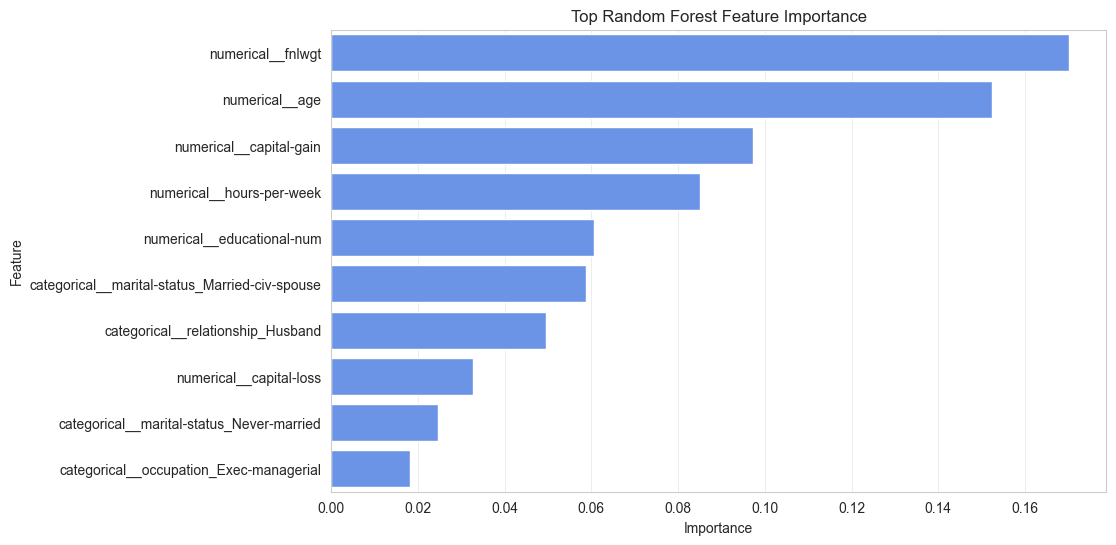

In [86]:
# Visualize top Random Forest feature importance
top_random_forest_features = (
    random_forest_importance_df.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_random_forest_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The Random Forest feature importance analysis highlights the variables that contribute most strongly to predictive performance across the ensemble of decision trees. Features related to capital gain, education, marital status, occupation, and age appear among the most influential predictors. Compared to Logistic Regression, Random Forest is able to capture more complex nonlinear relationships between features and income level.

## SHAP Model Interpretability

SHAP was used to explain how the Random Forest model makes predictions. This helps identify which features contribute most strongly to the model output.

In [87]:
X_shap_sample = X_test.sample(
    n=300,
    random_state=RANDOM_STATE
)

In [88]:
best_rf_pipeline = random_forest_grid_search.best_estimator_

preprocessor = best_rf_pipeline.named_steps["preprocessor"]
rf_model = best_rf_pipeline.named_steps["classifier"]

X_shap_transformed = preprocessor.transform(X_shap_sample)

In [89]:
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

In [90]:
feature_names = preprocessor.get_feature_names_out()

In [91]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(
    X_shap_transformed
)

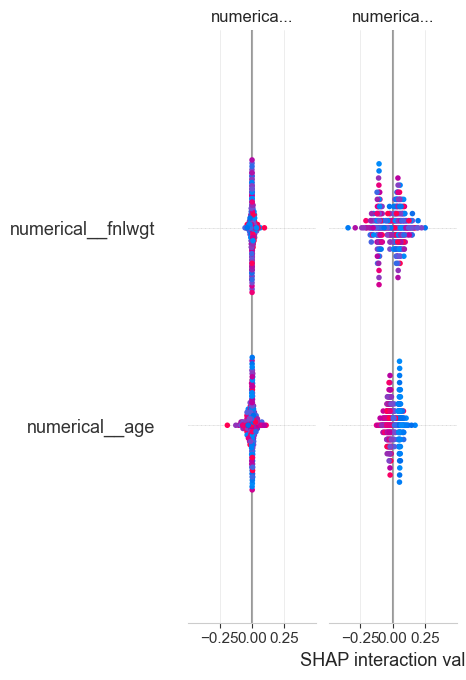

In [92]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    show=True
)

The SHAP summary plot shows the most influential features in the Random Forest model. Features at the top have the strongest overall impact on predictions. This improves model transparency by showing not only which variables are important, but also how they influence the prediction direction.

## Final Model Comparison Summary

In [93]:
# Final model comparison table
final_summary_df = final_results_df.copy()

final_summary_df = final_summary_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_summary_df.reset_index(
    drop=True,
    inplace=True
)

final_summary_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Random Forest,0.851916,0.716367,0.631421,0.671217,0.578055,0.899509
1,Tuned Logistic Regression,0.846280,0.733259,0.562500,0.636628,0.548936,0.899983
2,Tuned Decision Tree,0.845768,0.743981,0.542380,0.627383,0.543720,0.882040


## Best Model Selection

Based on the evaluation results, the Random Forest classifier was selected as the best-performing model for this project. Although Logistic Regression achieved highly competitive performance and slightly stronger ROC-AUC results, Random Forest obtained the highest F1-score and Matthews Correlation Coefficient, indicating stronger balanced classification performance across both income classes.

The results suggest that ensemble-based methods are effective for capturing complex nonlinear relationships within structured socioeconomic datasets. However, Logistic Regression remains valuable due to its stronger interpretability and lower computational complexity.

## Model Persistence and Reproducibility

In this section, the best-performing trained model is saved using `joblib` to support reproducibility and efficient reuse. Model persistence allows the trained pipeline to be stored on disk and reloaded later without repeating the training process.

Because the project uses Scikit-learn pipelines, both preprocessing and classification steps are saved together. After saving, the model is reloaded and tested to verify that predictions can still be generated correctly.

In [94]:
# Create directory for saved models
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

# Path to saved model
best_model_path = MODEL_DIR / "best_random_forest_model.joblib"

# Save trained model
joblib.dump(
    best_random_forest_model,
    best_model_path
)

print(f"Best model saved to: {best_model_path}")

Best model saved to: models/best_random_forest_model.joblib


In [95]:
# Reload saved model
loaded_model = joblib.load(best_model_path)

# Generate predictions
loaded_predictions = loaded_model.predict(X_test)

print("Loaded model works successfully.")

print(loaded_predictions[:10])

Loaded model works successfully.
['<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K'
 '<=50K']


In [96]:
def predict_income(
    model,
    input_data: pd.DataFrame
) -> np.ndarray:
    """
    Predict income class for new observations.

    Parameters
    ----------
    model
        Trained machine learning pipeline.

    input_data : pd.DataFrame
        Input observations.

    Returns
    -------
    np.ndarray
        Predicted income classes.
    """

    return model.predict(input_data)

In [97]:
# Select one sample observation
sample_person = X_test.head(1)

# Predict income
prediction = predict_income(
    model=loaded_model,
    input_data=sample_person
)

print("Predicted income class:")

print(prediction)

Predicted income class:
['<=50K']


## Critical Discussion and Ethical Considerations

Although the machine learning models achieved strong predictive performance, several important limitations and ethical considerations must be acknowledged when interpreting the results.

The Adult Income dataset contains demographic and socioeconomic variables that may reflect historical and societal inequalities. Features such as education level, occupation, marital status, race, and sex may indirectly encode structural biases present in the original population and data collection process. As a result, high predictive performance does not necessarily imply fairness or unbiased decision-making.

The results also demonstrate the importance of balanced evaluation metrics in imbalanced classification problems. Although the baseline classifier achieved relatively high accuracy, it completely failed to identify individuals in the higher-income class. This highlights why metrics such as Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient are necessary for more reliable evaluation.

From a modeling perspective, Random Forest achieved the strongest overall predictive performance, particularly in terms of F1-score and MCC. However, Logistic Regression remained highly competitive while offering greater interpretability and transparency. This illustrates an important trade-off in machine learning between predictive performance and explainability.

The project also demonstrates the importance of structured preprocessing and reproducible machine learning pipelines. Separating preprocessing from modeling through Scikit-learn pipelines helped reduce data leakage risk and ensured consistent transformations across all models and experiments.

Finally, while the models achieved strong performance on the available dataset, their predictions should not be interpreted as causal explanations of income inequality. The models identify statistical patterns rather than underlying social or economic causes.

## Conclusion

This project explored the application of machine learning techniques for income classification using the Adult Income dataset. A complete and reproducible machine learning pipeline was developed, including data loading, exploratory data analysis, preprocessing, feature engineering, model training, hyperparameter tuning, evaluation, fairness analysis, and interpretability analysis.

The exploratory analysis revealed important socioeconomic patterns related to income level, particularly across education, occupation, marital status, and capital gain variables. Missing values, duplicate records, and categorical encoding challenges were addressed through structured preprocessing pipelines to ensure robust and reproducible model training.

Multiple classification models were evaluated, including Logistic Regression, Decision Tree, and Random Forest classifiers. The results demonstrated that all trained models substantially outperformed the baseline classifier, confirming that meaningful predictive patterns exist within the dataset. Among the evaluated models, Random Forest achieved the strongest overall classification performance, particularly in terms of F1-score, ROC-AUC, and Matthews Correlation Coefficient, while Logistic Regression remained highly competitive and offered greater interpretability and stronger generalization characteristics.

The project also highlighted the importance of balanced evaluation metrics in imbalanced classification problems. Metrics such as Recall, F1-score, ROC-AUC, and MCC provided more reliable assessment than accuracy alone. Cross-validation analysis further demonstrated model robustness and stability across different validation folds.

In addition, interpretability analysis using feature importance and SHAP values helped identify the variables that most strongly influenced model predictions, improving model transparency and explainability. Fairness analysis across demographic groups also demonstrated that model performance may vary across sensitive attributes such as sex and race, emphasizing the importance of responsible AI practices in predictive modeling systems.

Despite the strong results, several limitations should be acknowledged. The Adult Income dataset is relatively old and may not fully reflect modern socioeconomic conditions. Furthermore, machine learning models identify statistical associations rather than causal relationships, meaning that correlation should not be interpreted as causation. The dataset may also contain historical or demographic biases that influence model predictions. In addition, synthetic balancing techniques such as SMOTE may slightly alter the original class distribution and introduce artificial patterns into the training process.

Future work could extend this project by evaluating more advanced models such as XGBoost, LightGBM, or deep learning approaches. Additional fairness-aware machine learning techniques could also be explored to reduce demographic disparities between groups. Moreover, future systems could incorporate real-time prediction pipelines, interactive explainable AI dashboards, and continuous fairness monitoring frameworks to improve transparency and real-world applicability.

Overall, this project demonstrated how machine learning can effectively identify statistical income patterns while emphasizing the importance of reproducibility, interpretability, fairness, and responsible evaluation in socioeconomic predictive modeling.

Although the models achieved strong predictive performance, it is important to recognize several limitations and ethical considerations. The dataset contains demographic and socioeconomic variables that may reflect historical inequalities and societal biases. Therefore, strong predictive performance does not necessarily imply fairness or unbiased decision-making.

The project also demonstrates the importance of balanced evaluation metrics. The baseline classifier achieved relatively high accuracy while completely failing to detect the minority class, highlighting why metrics such as Recall, F1-score, ROC-AUC, and MCC are necessary for reliable evaluation.

From a modeling perspective, Random Forest achieved the strongest predictive performance, while Logistic Regression remained highly competitive and offered greater interpretability. This illustrates the trade-off between predictive performance and explainability in machine learning systems.

Finally, the models identify statistical relationships within the dataset, but these predictions should not be interpreted as causal explanations of income inequality.